In [32]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler,KBinsDiscretizer


In [3]:
df = pd.read_csv('/content/Animation_Movies.csv')

In [4]:
# Clustering(1)-Step 1: preprocess the data
def preprocess_data(df):
    # Selecting numerical features
    features = df[['vote_average', 'vote_count', 'runtime', 'revenue']]

    # Handling missing values
    features = features.fillna(features.median())

    # Scaling the data
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    return scaled_features

In [5]:
# Clustering(1)-Step 2: KMeans Clustering
def perform_kmeans_clustering(data):
    # Finding the optimal number of clusters using Elbow Method
    inertia = []
    cluster_range = range(2, 10)
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)

    # Plotting the Elbow Method
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia, marker='o')
    plt.title("Elbow Method for Optimal K (KMeans)")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.show()

    # Applying KMeans with an optimal number of clusters
    optimal_k = 4  # Adjust based on the elbow plot
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    # Evaluating KMeans clustering
    silhouette = silhouette_score(data, labels)
    print(f"Silhouette Score for KMeans: {silhouette:.3f}")

    return labels

In [6]:
# Clustering(1)-Step 3: DBSCAN Clustering
def perform_dbscan_clustering(data):
    dbscan_configs = [
        {'eps': 0.5, 'min_samples': 5},
        {'eps': 0.7, 'min_samples': 5},
        {'eps': 0.3, 'min_samples': 10},
    ]

    dbscan_results = []
    for config in dbscan_configs:
        dbscan = DBSCAN(eps=config['eps'], min_samples=config['min_samples'])
        labels = dbscan.fit_predict(data)
        if len(set(labels)) > 1:  # Avoid silhouette score if only one cluster is found
            score = silhouette_score(data, labels)
            dbscan_results.append((config, score))
        else:
            dbscan_results.append((config, "Single cluster found"))

    # Printing DBSCAN results
    for config, result in dbscan_results:
        print(f"DBSCAN Config: {config}, Result: {result}")

    # Returning the best configuration
    best_config = max(dbscan_results, key=lambda x: x[1] if isinstance(x[1], float) else -1)
    return best_config

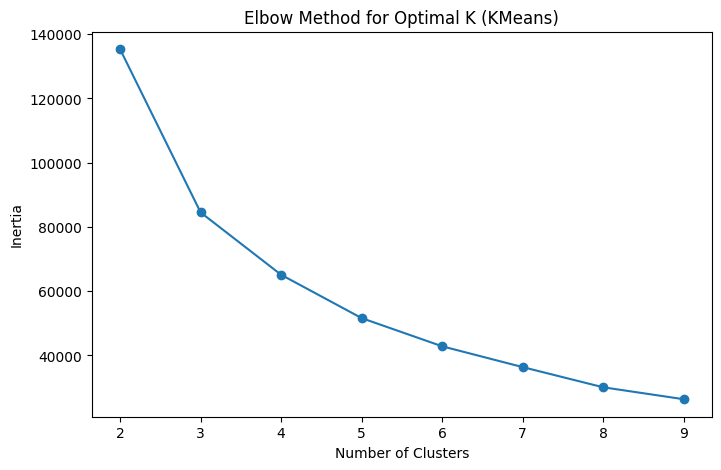

Silhouette Score for KMeans: 0.704


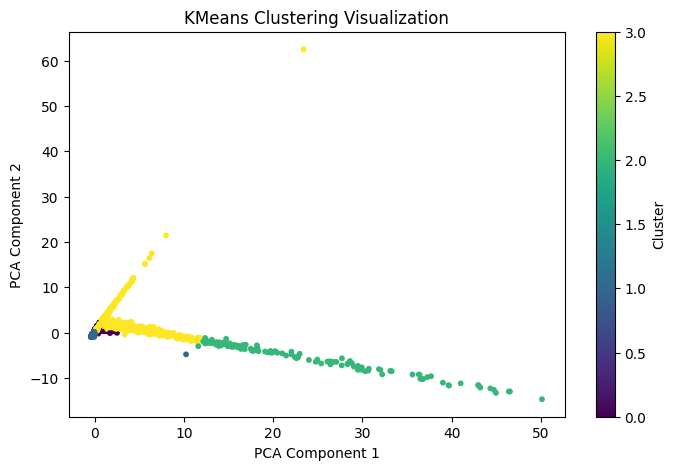

DBSCAN Config: {'eps': 0.5, 'min_samples': 5}, Result: 0.6083019738579033
DBSCAN Config: {'eps': 0.7, 'min_samples': 5}, Result: 0.6357348181794636
DBSCAN Config: {'eps': 0.3, 'min_samples': 10}, Result: 0.7826752650973807


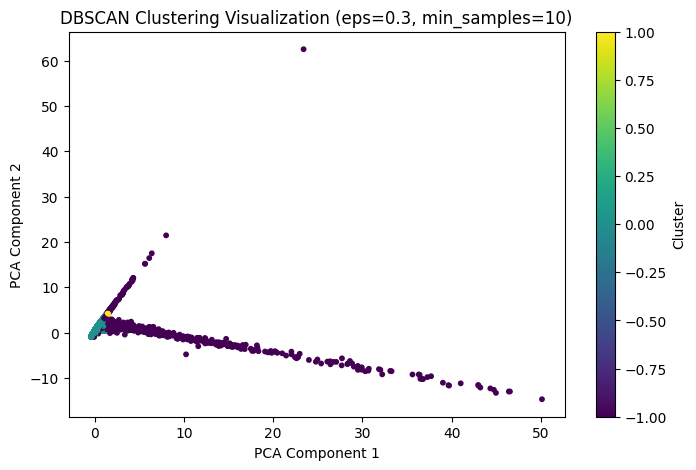

In [8]:
# Clustering(1)-Step 4: Visualization
def visualize_clusters(data, labels, title):
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(data)

    plt.figure(figsize=(8, 5))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(label="Cluster")
    plt.show()

# Main Execution
if __name__ == "__main__":

    # Preprocess the data
    scaled_data = preprocess_data(df)

    # Perform KMeans Clustering
    kmeans_labels = perform_kmeans_clustering(scaled_data)

    # Visualize KMeans Clustering
    visualize_clusters(scaled_data, kmeans_labels, "KMeans Clustering Visualization")

    # Perform DBSCAN Clustering
    best_dbscan_config = perform_dbscan_clustering(scaled_data)
    if isinstance(best_dbscan_config[1], float):
        dbscan = DBSCAN(**best_dbscan_config[0])
        dbscan_labels = dbscan.fit_predict(scaled_data)

        # Visualize DBSCAN Clustering
        visualize_clusters(scaled_data, dbscan_labels, f"DBSCAN Clustering Visualization (eps={best_dbscan_config[0]['eps']}, min_samples={best_dbscan_config[0]['min_samples']})")


In [17]:
# Clustering(2)-Step 1: Load and preprocess the data
def preprocess_data_by_season(df):
    # Convert release_date to datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    # Extract year and season
    df['year'] = df['release_date'].dt.year
    df['month'] = df['release_date'].dt.month
    df['season'] = df['month'].apply(lambda x:
                                     'Winter' if x in [12, 1, 2] else
                                     'Spring' if x in [3, 4, 5] else
                                     'Summer' if x in [6, 7, 8] else 'Fall')

    # Drop rows with missing values in relevant columns
    df = df.dropna(subset=['year', 'season'])

    # Select features for clustering
    features = df[['year', 'season']]

    # Encode categorical features (e.g., season)
    features = pd.get_dummies(features, columns=['season'], drop_first=True)

    # Scale numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    return scaled_features, df.reset_index(drop=True)
    # Convert release_date to datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    # Extract year and season
    df['year'] = df['release_date'].dt.year
    df['month'] = df['release_date'].dt.month
    df['season'] = df['month'].apply(lambda x:
                                     'Winter' if x in [12, 1, 2] else
                                     'Spring' if x in [3, 4, 5] else
                                     'Summer' if x in [6, 7, 8] else 'Fall')

    # Select features for clustering
    features = df[['year', 'season']]

    # Drop rows with missing values in features
    features = features.dropna()

    # Encode categorical features (e.g., season)
    features = pd.get_dummies(features, columns=['season'], drop_first=True)

    # Scale numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    return scaled_features, df
    # Convert release_date to datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    # Extract year and season
    df['year'] = df['release_date'].dt.year
    df['month'] = df['release_date'].dt.month
    df['season'] = df['month'].apply(lambda x:
                                     'Winter' if x in [12, 1, 2] else
                                     'Spring' if x in [3, 4, 5] else
                                     'Summer' if x in [6, 7, 8] else 'Fall')

    # Select features for clustering
    features = df[['year', 'season']]

    # Encode categorical features (e.g., season)
    features = pd.get_dummies(features, columns=['season'], drop_first=True)

    # Scale numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    return scaled_features, df

In [ ]:
# Clustering(2)-Step 2: Visualization
def visualize_clusters(data, labels, title):
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(data)

    plt.figure(figsize=(8, 5))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(label="Cluster")
    plt.show()

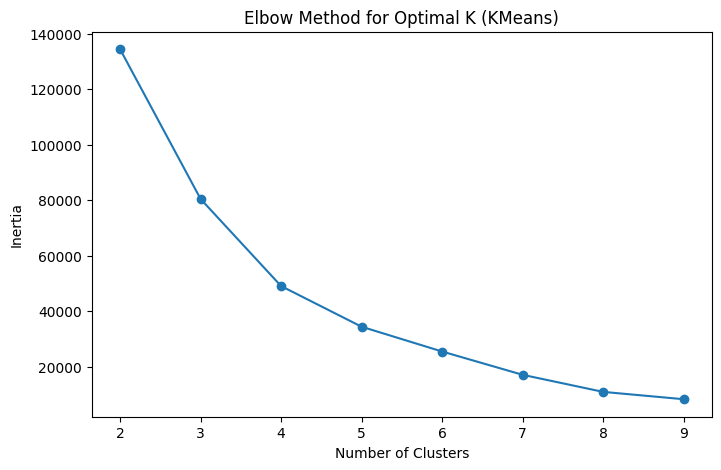

Silhouette Score for KMeans: 0.612


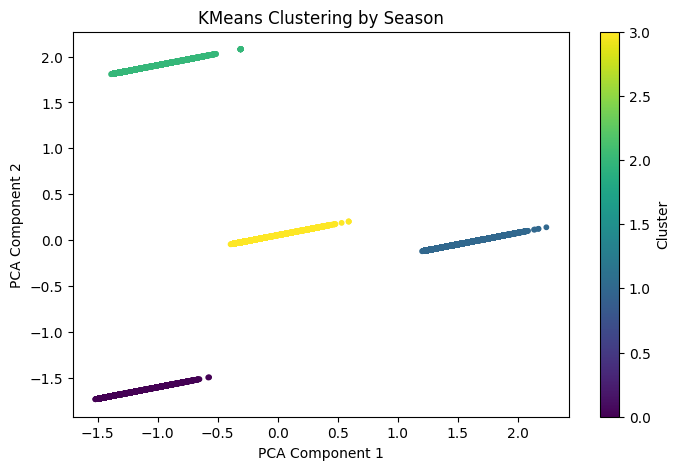

DBSCAN Config: {'eps': 0.5, 'min_samples': 5}, Result: 0.600621371561058
DBSCAN Config: {'eps': 0.7, 'min_samples': 5}, Result: 0.600621371561058
DBSCAN Config: {'eps': 0.3, 'min_samples': 10}, Result: 0.5852750314393724


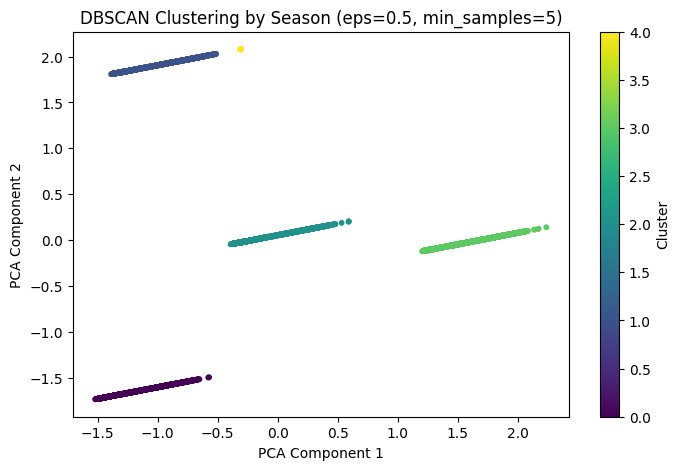

Season Distribution by Cluster:
 cluster  season
0        Summer    1.0
1        Winter    1.0
2        Spring    1.0
3        Fall      1.0
Name: proportion, dtype: float64
Top Genres by Cluster:
 cluster                   
0        Animation             5126
         Animation, Comedy      546
         Animation, Family      345
1        Animation            11123
         Animation, Family      919
         Animation, Comedy      807
2        Animation             5164
         Animation, Comedy      516
         Animation, Family      351
3        Animation             5845
         Animation, Comedy      553
         Animation, Family      539
Name: genres, dtype: int64


In [19]:
# Clustering(2)-Step 3: Analyze Clusters
def analyze_clusters(df, labels):
    df['cluster'] = labels

    # Distribution of seasons per cluster
    season_distribution = df.groupby('cluster')['season'].value_counts(normalize=True)
    print("Season Distribution by Cluster:\n", season_distribution)

    # Distribution of genres per cluster
    if 'genres' in df.columns:
        genre_distribution = df.groupby('cluster')['genres'].apply(lambda x: x.value_counts().head(3))
        print("Top Genres by Cluster:\n", genre_distribution)

# Main Execution
if __name__ == "__main__":

    # Preprocess the data by season
    scaled_data, processed_df = preprocess_data_by_season(df)

    # Perform KMeans Clustering
    kmeans_labels = perform_kmeans_clustering(scaled_data)

    # Visualize KMeans Clustering
    visualize_clusters(scaled_data, kmeans_labels, "KMeans Clustering by Season")

    # Perform DBSCAN Clustering
    best_dbscan_config = perform_dbscan_clustering(scaled_data)
    if isinstance(best_dbscan_config[1], float):
        dbscan = DBSCAN(**best_dbscan_config[0])
        dbscan_labels = dbscan.fit_predict(scaled_data)

        # Visualize DBSCAN Clustering
        visualize_clusters(scaled_data, dbscan_labels, f"DBSCAN Clustering by Season (eps={best_dbscan_config[0]['eps']}, min_samples={best_dbscan_config[0]['min_samples']})")

    # Analyze Clusters
    analyze_clusters(processed_df, kmeans_labels)


In [26]:
# Classification(1)-Step 1: Create `is_popular` label
def create_popularity_label(df):
    # Define a threshold for popularity (customizable)
    vote_count_threshold = df['vote_count'].median()
    vote_average_threshold = 7.0

    df['is_popular'] = ((df['vote_count'] > vote_count_threshold) & (df['vote_average'] >= vote_average_threshold)).astype(int)
    return df

In [27]:
# Classification(1)-Step 2: Select relevant features and preprocess data
def preprocess_features(df):
    features = df[['vote_average', 'vote_count', 'runtime', 'revenue']].fillna(0)
    labels = df['is_popular']

    # Scale numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    return scaled_features, labels

In [28]:
# Classification(1)-Step 3: Train and evaluate models
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(random_state=42),
        'Naive Bayes': GaussianNB(),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
    }

    tuned_parameters = {
        'Decision Tree': {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]},
        'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'Naive Bayes': {},
        'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
        'Logistic Regression': {'C': [0.01, 0.1, 1, 10]}
    }

    results = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        # Hyperparameter tuning
        if tuned_parameters[model_name]:
            grid = GridSearchCV(model, tuned_parameters[model_name], scoring='accuracy', cv=5)
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
        else:
            best_model = model

        # Train the model
        best_model.fit(X_train, y_train)

        # Train accuracy
        train_accuracy = accuracy_score(y_train, best_model.predict(X_train))

        # Test predictions and metrics
        y_pred = best_model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        results[model_name] = {
            'Train Accuracy': train_accuracy,
            'Test Accuracy': test_accuracy,
            'Classification Report': report
        }

    return results

# Main Execution
if __name__ == "__main__":

    # Create popularity label
    animation_movies_df = create_popularity_label(df)

    # Preprocess features and labels
    X, y = preprocess_features(animation_movies_df)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train and evaluate models
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

    # Display results
    for model_name, metrics in results.items():
        print(f"\n{model_name} Results:")
        print(f"Train Accuracy: {metrics['Train Accuracy']:.2f}")
        print(f"Test Accuracy: {metrics['Test Accuracy']:.2f}")
        print(f"Classification Report:\n{metrics['Classification Report']}")



Training Decision Tree...

Training SVM...

Training Naive Bayes...

Training Random Forest...

Training Logistic Regression...

Decision Tree Results:
Train Accuracy: 1.00
Test Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8898
           1       1.00      1.00      1.00      1491

    accuracy                           1.00     10389
   macro avg       1.00      1.00      1.00     10389
weighted avg       1.00      1.00      1.00     10389


SVM Results:
Train Accuracy: 1.00
Test Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8898
           1       0.99      1.00      0.99      1491

    accuracy                           1.00     10389
   macro avg       0.99      1.00      1.00     10389
weighted avg       1.00      1.00      1.00     10389


Naive Bayes Results:
Train Accuracy: 0.88
Test Acc

In [29]:
# Classificaion(2)-Step 1: Create categorical `vote_average` label
def create_vote_average_label(df):
    # Discretize `vote_average` into categorical bins
    discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
    df['vote_average_category'] = discretizer.fit_transform(df[['vote_average']].fillna(0)).astype(int)
    return df

In [30]:
# Classificaion(2)-Step 2: Select relevant features and preprocess data
def preprocess_features_for_vote_average(df):
    # Select relevant features
    features = df[['vote_count', 'runtime', 'revenue']].fillna(0)
    labels = df['vote_average_category']

    # Scale numerical features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    return scaled_features, labels

In [34]:
# Classificaion(2)-Step 3: Train and evaluate models
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(random_state=42),
        'Naive Bayes': GaussianNB(),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
    }

    tuned_parameters = {
        'Decision Tree': {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]},
        'SVM': {'C': [0.1, 1], 'kernel': ['linear']},
        'Naive Bayes': {},
        'Random Forest': {'n_estimators': [50, 100], 'max_depth': [None, 10]},
        'Logistic Regression': {'C': [0.01, 0.1, 1]}
    }

    results = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        # Hyperparameter tuning
        if tuned_parameters[model_name]:
            grid = GridSearchCV(model, tuned_parameters[model_name], scoring='accuracy', cv=5)
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
        else:
            best_model = model

        # Train the model
        best_model.fit(X_train, y_train)

        # Train accuracy
        train_accuracy = accuracy_score(y_train, best_model.predict(X_train))

        # Test predictions and metrics
        y_pred = best_model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        results[model_name] = {
            'Train Accuracy': train_accuracy,
            'Test Accuracy': test_accuracy,
            'Classification Report': report
        }

    return results

# Main Execution
if __name__ == "__main__":

    # Create categorical vote average label
    animation_movies_df = create_vote_average_label(df)

    # Preprocess features and labels
    X, y = preprocess_features_for_vote_average(animation_movies_df)

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Limit data size for faster computation (optional)
    X_train = X_train[:1000]
    y_train = y_train[:1000]

    # Train and evaluate models
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

    # Display results
    for model_name, metrics in results.items():
        print(f"\n{model_name} Results:")
        print(f"Train Accuracy: {metrics['Train Accuracy']:.2f}")
        print(f"Test Accuracy: {metrics['Test Accuracy']:.2f}")
        print(f"Classification Report:\n{metrics['Classification Report']}")



Training Decision Tree...

Training SVM...

Training Naive Bayes...

Training Random Forest...

Training Logistic Regression...

Decision Tree Results:
Train Accuracy: 0.83
Test Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      6336
           1       0.58      0.84      0.68      2224
           2       0.58      0.32      0.42      1829

    accuracy                           0.83     10389
   macro avg       0.72      0.71      0.69     10389
weighted avg       0.84      0.83      0.82     10389


SVM Results:
Train Accuracy: 0.62
Test Accuracy: 0.63
Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77      6336
           1       0.33      0.04      0.07      2224
           2       0.82      0.05      0.10      1829

    accuracy                           0.63     10389
   macro avg       0.59      0.36      0.31     1038